In [2]:
# Install Dependencies
import subprocess, sys

packages = [
    "gymnasium",
    "stable-baselines3",
    "boto3",
    "matplotlib",
    "pandas",
    "numpy",
    "torch"
]

for pkg in packages:
    subprocess.run(
        [sys.executable, "-m", "pip", "install", pkg, "-q"],
        capture_output=True
    )

print("✅ All packages installed!")

✅ All packages installed!


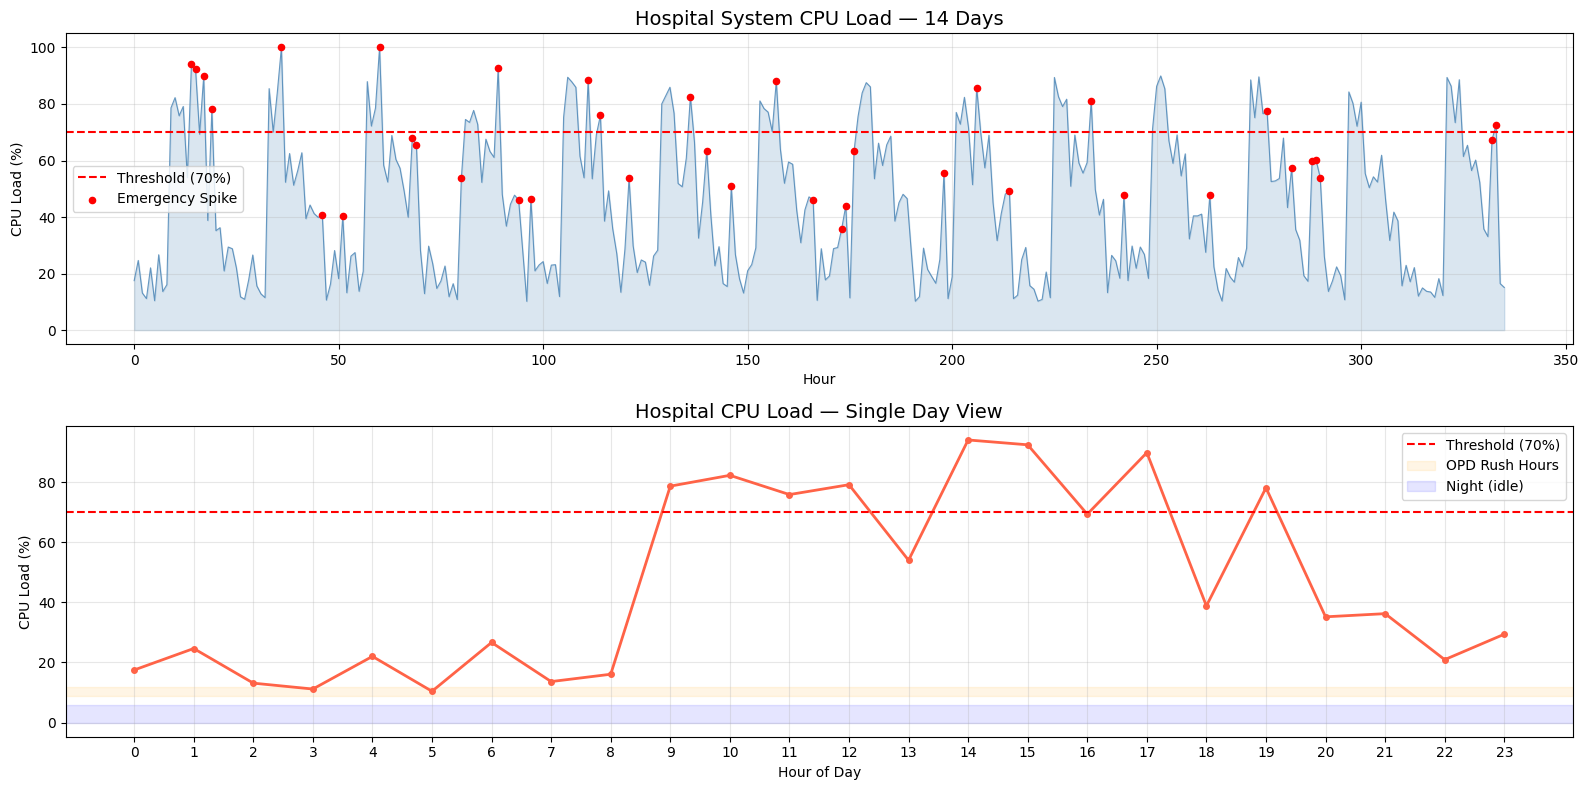

  📊 Hospital Workload Statistics
  Total hours simulated : 336
  Average CPU load      : 44.8%
  Peak CPU load         : 100.0%
  Hours above 70%       : 69
  Emergency spikes      : 38


In [3]:
# Build the Hospital Workload Simulator : This generates realistic hospital traffic patterns — busy mornings, quiet nights, emergency spikes
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(42)

def generate_hospital_workload(days=14):
    """
    Generates realistic hospital CPU load patterns:
    - Morning OPD rush (9am-12pm)
    - Afternoon moderate (12pm-5pm)
    - Evening drop (5pm-9pm)
    - Night minimal (9pm-9am)
    - Random emergency spikes
    """
    hours = days * 24
    workload = []

    for hour in range(hours):
        hour_of_day = hour % 24

        # Base load by time of day
        if 9 <= hour_of_day <= 12:
            base = np.random.uniform(70, 90)   # OPD rush
        elif 13 <= hour_of_day <= 17:
            base = np.random.uniform(50, 70)   # Afternoon
        elif 18 <= hour_of_day <= 21:
            base = np.random.uniform(30, 50)   # Evening
        else:
            base = np.random.uniform(10, 30)   # Night

        # Random emergency spike (10% chance any hour)
        spike = np.random.uniform(20, 40) \
                if np.random.random() < 0.10 else 0

        cpu_load = min(100, base + spike)
        workload.append({
            "hour":        hour,
            "hour_of_day": hour_of_day,
            "day":         hour // 24 + 1,
            "cpu_load":    round(cpu_load, 2),
            "is_spike":    spike > 0
        })

    return pd.DataFrame(workload)

# Generate 14 days of hospital workload
df = generate_hospital_workload(days=14)

# ── Plot ──────────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(16, 8))

# Full 14-day view
axes[0].plot(df["hour"], df["cpu_load"],
             color="steelblue", linewidth=0.8, alpha=0.8)
axes[0].fill_between(df["hour"], df["cpu_load"],
                      alpha=0.2, color="steelblue")
axes[0].axhline(y=70, color="red", linestyle="--",
                linewidth=1.5, label="Threshold (70%)")
axes[0].scatter(df[df["is_spike"]]["hour"],
                df[df["is_spike"]]["cpu_load"],
                color="red", s=20, zorder=5,
                label="Emergency Spike")
axes[0].set_title("Hospital System CPU Load — 14 Days",
                   fontsize=14)
axes[0].set_xlabel("Hour")
axes[0].set_ylabel("CPU Load (%)")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Single day view (Day 1)
day1 = df[df["day"] == 1]
axes[1].plot(day1["hour_of_day"], day1["cpu_load"],
             color="tomato", linewidth=2, marker="o",
             markersize=4)
axes[1].axhline(y=70, color="red", linestyle="--",
                linewidth=1.5, label="Threshold (70%)")
axes[1].axhspan(9, 12, alpha=0.1, color="orange",
                label="OPD Rush Hours")
axes[1].axhspan(0, 6, alpha=0.1, color="blue",
                label="Night (idle)")
axes[1].set_title("Hospital CPU Load — Single Day View",
                   fontsize=14)
axes[1].set_xlabel("Hour of Day")
axes[1].set_ylabel("CPU Load (%)")
axes[1].set_xticks(range(0, 24))
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("hospital_workload.png", dpi=150)
plt.show()

# Stats
print(f"{'='*50}")
print(f"  📊 Hospital Workload Statistics")
print(f"{'='*50}")
print(f"  Total hours simulated : {len(df)}")
print(f"  Average CPU load      : {df['cpu_load'].mean():.1f}%")
print(f"  Peak CPU load         : {df['cpu_load'].max():.1f}%")
print(f"  Hours above 70%       : {(df['cpu_load']>70).sum()}")
print(f"  Emergency spikes      : {df['is_spike'].sum()}")
print(f"{'='*50}")

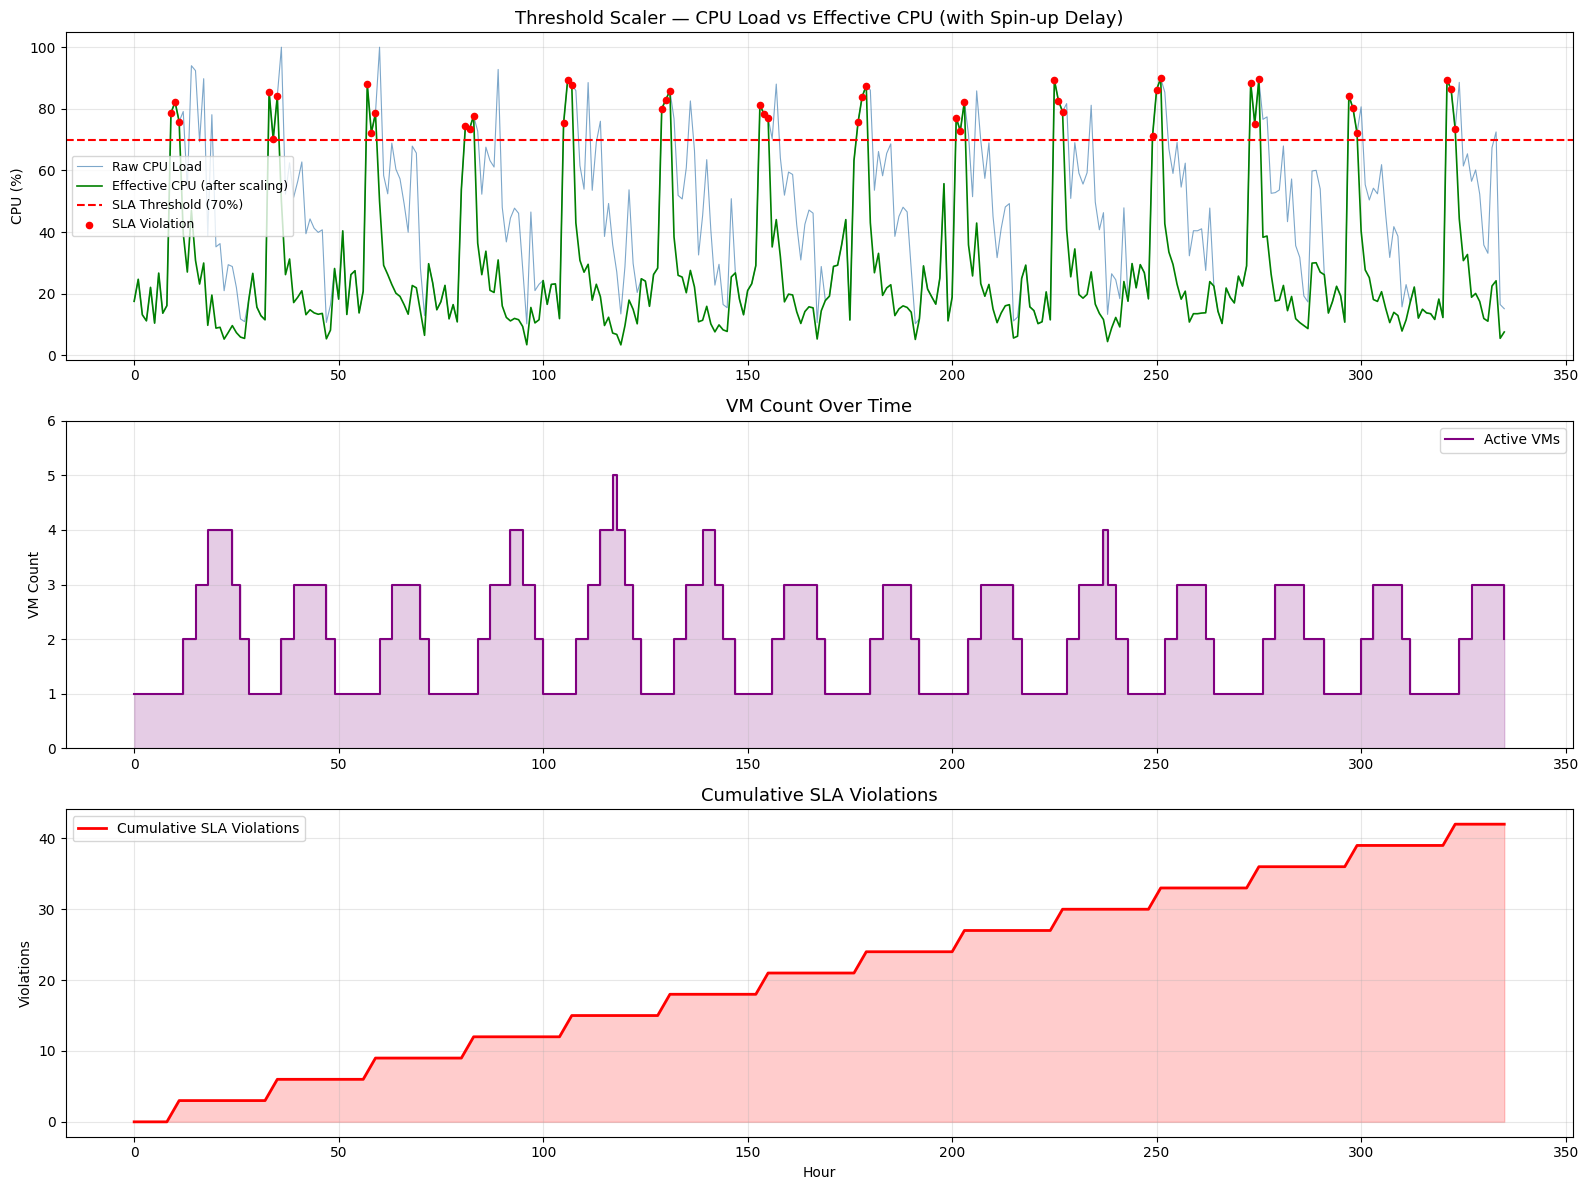

  📊 Threshold Scaler Results (Baseline)
  SLA violations        : 42
  Total VM hours        : 666
  Average VMs running   : 1.98
  Estimated cost (14d)  : $6.93
  ⚠️  These are the numbers your RL agent will beat!


In [4]:
class ThresholdScaler:
    """
    Realistic AWS auto-scaling with spin-up delay:
    - Scale out triggered at CPU > 70%
    - BUT new VM takes 3 hours to become active (realistic)
    - During spin-up → SLA violated
    - Cooldown: 2 hours
    """
    def __init__(self, scale_out_threshold=70,
                       scale_in_threshold=30,
                       min_vms=1, max_vms=5,
                       cooldown=2, spinup_delay=3):
        self.scale_out_threshold = scale_out_threshold
        self.scale_in_threshold  = scale_in_threshold
        self.min_vms             = min_vms
        self.max_vms             = max_vms
        self.cooldown            = cooldown
        self.spinup_delay        = spinup_delay
        self.current_vms         = 1
        self.pending_vms         = 0
        self.pending_at_hour     = -999
        self.last_action_hour    = -cooldown
        self.sla_violations      = 0
        self.total_vm_hours      = 0
        self.history             = []

    def step(self, hour, cpu_load):
        action  = "hold"
        sla_hit = False

        # Activate pending VM after spinup delay
        if self.pending_vms > 0 and \
           (hour - self.pending_at_hour) >= self.spinup_delay:
            self.current_vms += self.pending_vms
            self.current_vms  = min(self.current_vms, self.max_vms)
            self.pending_vms  = 0

        can_act = (hour - self.last_action_hour) >= self.cooldown

        # Scale out decision
        if cpu_load > self.scale_out_threshold and can_act:
            if self.current_vms < self.max_vms and \
               self.pending_vms == 0:
                self.pending_vms     = 1
                self.pending_at_hour = hour
                action               = "scale_out_pending"
                self.last_action_hour = hour

        # Scale in decision
        elif cpu_load < self.scale_in_threshold and can_act:
            if self.current_vms > self.min_vms:
                self.current_vms    -= 1
                action               = "scale_in"
                self.last_action_hour = hour

        # Effective CPU after current (active) VMs
        effective_cpu = cpu_load / self.current_vms

        # SLA violation check
        if effective_cpu > self.scale_out_threshold:
            self.sla_violations += 1
            sla_hit = True

        self.total_vm_hours += self.current_vms
        self.history.append({
            "hour":          hour,
            "cpu_load":      cpu_load,
            "vms":           self.current_vms,
            "effective_cpu": round(effective_cpu, 2),
            "action":        action,
            "sla_violation": sla_hit
        })

    def run(self, workload_df):
        for _, row in workload_df.iterrows():
            self.step(int(row["hour"]), float(row["cpu_load"]))
        return pd.DataFrame(self.history)


# ── Run ───────────────────────────────────────────────
scaler           = ThresholdScaler()
result_threshold = scaler.run(df)

# ── Plot ──────────────────────────────────────────────
fig, axes = plt.subplots(3, 1, figsize=(16, 12))

axes[0].plot(result_threshold["hour"],
             result_threshold["cpu_load"],
             color="steelblue", linewidth=0.8,
             label="Raw CPU Load", alpha=0.7)
axes[0].plot(result_threshold["hour"],
             result_threshold["effective_cpu"],
             color="green", linewidth=1.2,
             label="Effective CPU (after scaling)")
axes[0].axhline(y=70, color="red", linestyle="--",
                label="SLA Threshold (70%)")
axes[0].scatter(
    result_threshold[result_threshold["sla_violation"]]["hour"],
    result_threshold[result_threshold["sla_violation"]]["effective_cpu"],
    color="red", s=20, zorder=5, label="SLA Violation")
axes[0].set_title(
    "Threshold Scaler — CPU Load vs Effective CPU (with Spin-up Delay)",
    fontsize=13)
axes[0].set_ylabel("CPU (%)")
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)

axes[1].step(result_threshold["hour"],
             result_threshold["vms"],
             color="purple", linewidth=1.5,
             where="post", label="Active VMs")
axes[1].fill_between(result_threshold["hour"],
                      result_threshold["vms"],
                      step="post", alpha=0.2, color="purple")
axes[1].set_title("VM Count Over Time", fontsize=13)
axes[1].set_ylabel("VM Count")
axes[1].set_ylim(0, 6)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

cumulative_sla = result_threshold["sla_violation"].cumsum()
axes[2].plot(result_threshold["hour"], cumulative_sla,
             color="red", linewidth=2,
             label="Cumulative SLA Violations")
axes[2].fill_between(result_threshold["hour"],
                      cumulative_sla,
                      alpha=0.2, color="red")
axes[2].set_title("Cumulative SLA Violations", fontsize=13)
axes[2].set_xlabel("Hour")
axes[2].set_ylabel("Violations")
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("threshold_scaler_results.png", dpi=150)
plt.show()

# ── Stats ─────────────────────────────────────────────
cost_per_vm_hour = 0.0104
total_cost       = scaler.total_vm_hours * cost_per_vm_hour

print(f"{'='*52}")
print(f"  📊 Threshold Scaler Results (Baseline)")
print(f"{'='*52}")
print(f"  SLA violations        : {scaler.sla_violations}")
print(f"  Total VM hours        : {scaler.total_vm_hours}")
print(f"  Average VMs running   : {result_threshold['vms'].mean():.2f}")
print(f"  Estimated cost (14d)  : ${total_cost:.2f}")
print(f"{'='*52}")
print(f"  ⚠️  These are the numbers your RL agent will beat!")
print(f"{'='*52}")

In [9]:
import gymnasium as gym
from gymnasium import spaces
import numpy as np

class HospitalCloudEnv(gym.Env):
    """
    Hospital Cloud Auto-Scaling RL Environment
    State  : [cpu_load, current_vms, hour_of_day, trend]
    Actions: 0=hold, 1=scale_out, 2=scale_in
    """

    def __init__(self, workload_df, spinup_delay=3,
                 max_vms=5, sla_threshold=70):
        super().__init__()
        self.workload        = workload_df.reset_index(drop=True)
        self.spinup_delay    = spinup_delay
        self.max_vms         = max_vms
        self.sla_threshold   = sla_threshold
        self.n_steps         = len(workload_df)

        self.action_space = spaces.Discrete(3)
        self.observation_space = spaces.Box(
            low  = np.array([0,   1, 0,  -1], dtype=np.float32),
            high = np.array([100, 5, 23,  1], dtype=np.float32)
        )
        self.reset()

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        self.current_step    = 0
        self.current_vms     = 1
        self.pending_vms     = 0
        self.pending_at_step = -999
        self.sla_violations  = 0
        self.total_vm_hours  = 0
        self.history         = []
        return self._get_obs(), {}

    def _get_obs(self):
        # ── Wrap around if we exceed dataset length ───────
        idx      = self.current_step % self.n_steps
        row      = self.workload.iloc[idx]
        cpu_load = float(row["cpu_load"])
        hour     = float(row["hour_of_day"])

        if self.current_step > 0:
            prev_idx = (self.current_step - 1) % self.n_steps
            prev     = float(self.workload.iloc[prev_idx]["cpu_load"])
            trend    = 1.0 if cpu_load > prev + 5 \
                       else (-1.0 if cpu_load < prev - 5 else 0.0)
        else:
            trend = 0.0

        return np.array([cpu_load, float(self.current_vms),
                         hour, trend], dtype=np.float32)

    def step(self, action):
        idx      = self.current_step % self.n_steps
        row      = self.workload.iloc[idx]
        cpu_load = float(row["cpu_load"])

        # Activate pending VM after spinup delay
        if self.pending_vms > 0 and \
           (self.current_step - self.pending_at_step) \
           >= self.spinup_delay:
            self.current_vms = min(
                self.current_vms + self.pending_vms,
                self.max_vms)
            self.pending_vms = 0

        # Execute action
        if action == 1:
            if self.current_vms < self.max_vms and \
               self.pending_vms == 0:
                self.pending_vms     = 1
                self.pending_at_step = self.current_step
        elif action == 2:
            if self.current_vms > 1:
                self.current_vms -= 1

        # Effective CPU
        effective_cpu = cpu_load / self.current_vms

        # Reward
        reward  = 0.0
        sla_hit = False

        if effective_cpu > self.sla_threshold:
            reward  -= 5.0
            sla_hit  = True
            self.sla_violations += 1
        else:
            reward  += 1.0

        reward -= 0.5 * (self.current_vms - 1)

        if action == 2 and cpu_load < 30:
            reward += 0.5

        self.total_vm_hours += self.current_vms
        self.history.append({
            "hour":          int(row["hour"]),
            "cpu_load":      cpu_load,
            "vms":           self.current_vms,
            "effective_cpu": round(effective_cpu, 2),
            "action":        action,
            "reward":        reward,
            "sla_violation": sla_hit
        })

        self.current_step += 1

        # ── Episode ends after one full cycle ─────────────
        done = (self.current_step % self.n_steps == 0)

        return self._get_obs(), reward, done, False, {}

print("✅ Environment (fixed) loaded successfully!")

✅ Environment (fixed) loaded successfully!


🔍 Checking environment compatibility...
✅ Environment check passed!

🤖 PPO Agent created!
   Policy network : MlpPolicy
   Learning rate  : 0.0003
   Training steps : 50,000

⏳ Training started — please wait 2-3 minutes...



/usr/local/lib/python3.12/dist-packages/stable_baselines3/ppo/ppo.py:155: UserWarning: You have specified a mini-batch size of 64, but because the `RolloutBuffer` is of size `n_steps * n_envs = 336`, after every 5 untruncated mini-batches, there will be a truncated mini-batch of size 16
We recommend using a `batch_size` that is a factor of `n_steps * n_envs`.
Info: (n_steps=336 and n_envs=1)
  warnings.warn(


  Progress:  10% | Episode Reward:   -25.5 | SLA Violations: 69
  Progress:  20% | Episode Reward:   137.0 | SLA Violations: 30
  Progress:  30% | Episode Reward:   112.0 | SLA Violations: 0
  Progress:  40% | Episode Reward:   100.5 | SLA Violations: 46
  Progress:  50% | Episode Reward:   235.0 | SLA Violations: 10
  Progress:  60% | Episode Reward:   222.5 | SLA Violations: 17
  Progress:  70% | Episode Reward:   245.5 | SLA Violations: 9
  Progress:  80% | Episode Reward:   244.0 | SLA Violations: 15
  Progress:  90% | Episode Reward:   249.0 | SLA Violations: 12
  Progress: 100% | Episode Reward:   249.5 | SLA Violations: 2

✅ Training Complete!


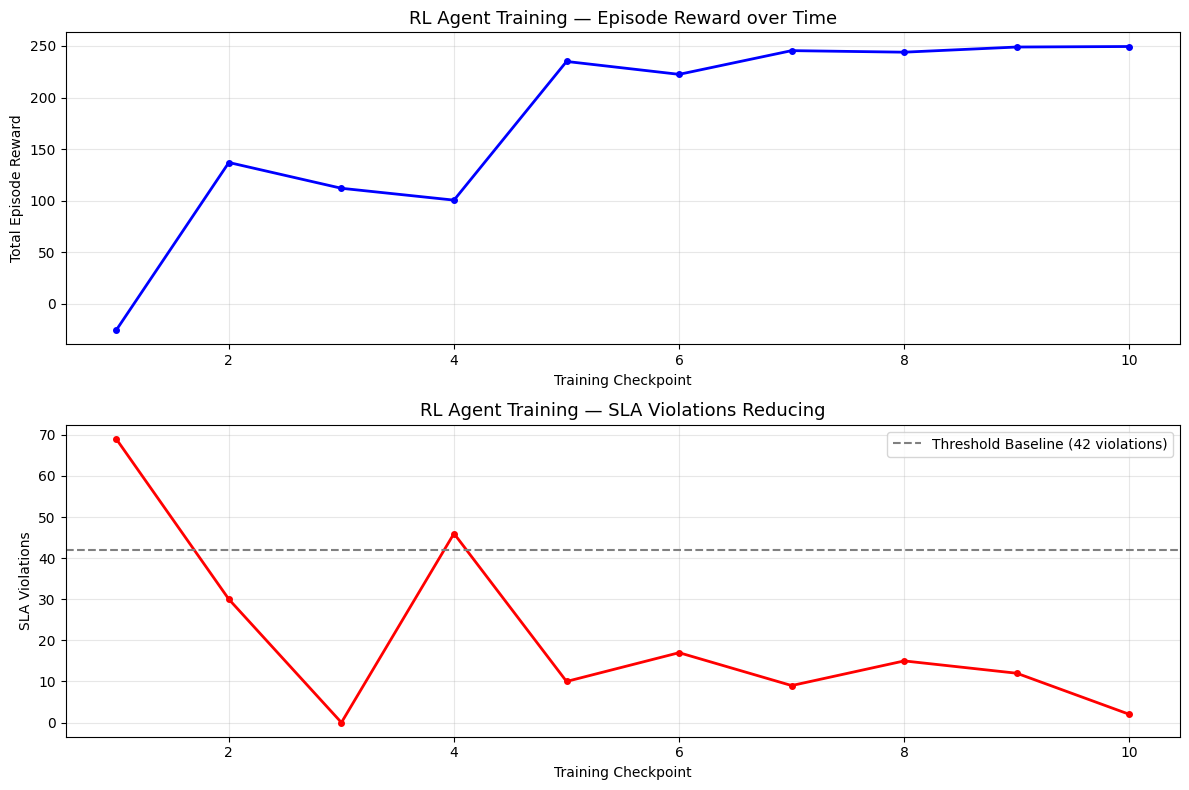


💾 Model saved as hospital_rl_agent.zip


In [10]:
from stable_baselines3 import PPO
from stable_baselines3.common.env_checker import check_env
import matplotlib.pyplot as plt
import numpy as np

# ── Verify environment is SB3 compatible ─────────────
print("🔍 Checking environment compatibility...")
check_env(HospitalCloudEnv(df), warn=True)
print("✅ Environment check passed!\n")

# ── Create training environment ───────────────────────
train_env = HospitalCloudEnv(df)

# ── Define PPO Agent ──────────────────────────────────
model = PPO(
    policy      = "MlpPolicy",  # Multi-layer perceptron
    env         = train_env,
    learning_rate = 0.0003,
    n_steps       = 336,        # One full episode
    batch_size    = 64,
    n_epochs      = 10,
    gamma         = 0.99,       # Discount factor
    verbose       = 0
)

print("🤖 PPO Agent created!")
print(f"   Policy network : MlpPolicy")
print(f"   Learning rate  : 0.0003")
print(f"   Training steps : 50,000")
print("\n⏳ Training started — please wait 2-3 minutes...\n")

# ── Train ─────────────────────────────────────────────
TOTAL_TIMESTEPS = 50000
reward_log      = []
sla_log         = []

# Train in chunks to track progress
chunk = 5000
for i in range(0, TOTAL_TIMESTEPS, chunk):
    model.learn(total_timesteps=chunk,
                reset_num_timesteps=(i == 0))

    # Evaluate current performance
    obs, _    = train_env.reset()
    done      = False
    ep_reward = 0
    while not done:
        action, _ = model.predict(obs, deterministic=True)
        obs, reward, done, _, _ = train_env.step(action)
        ep_reward += reward

    reward_log.append(ep_reward)
    sla_log.append(train_env.sla_violations)
    pct = int((i + chunk) / TOTAL_TIMESTEPS * 100)
    print(f"  Progress: {pct:3d}% | "
          f"Episode Reward: {ep_reward:7.1f} | "
          f"SLA Violations: {train_env.sla_violations}")

print("\n✅ Training Complete!")

# ── Plot Training Progress ────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(12, 8))

axes[0].plot(range(1, len(reward_log)+1),
             reward_log, 'b-o',
             linewidth=2, markersize=4)
axes[0].set_title("RL Agent Training — Episode Reward over Time",
                   fontsize=13)
axes[0].set_xlabel("Training Checkpoint")
axes[0].set_ylabel("Total Episode Reward")
axes[0].grid(True, alpha=0.3)

axes[1].plot(range(1, len(sla_log)+1),
             sla_log, 'r-o',
             linewidth=2, markersize=4)
axes[1].axhline(y=42, color="gray", linestyle="--",
                linewidth=1.5,
                label="Threshold Baseline (42 violations)")
axes[1].set_title("RL Agent Training — SLA Violations Reducing",
                   fontsize=13)
axes[1].set_xlabel("Training Checkpoint")
axes[1].set_ylabel("SLA Violations")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("rl_training_progress.png", dpi=150)
plt.show()

# Save model
model.save("hospital_rl_agent")
print("\n💾 Model saved as hospital_rl_agent.zip")

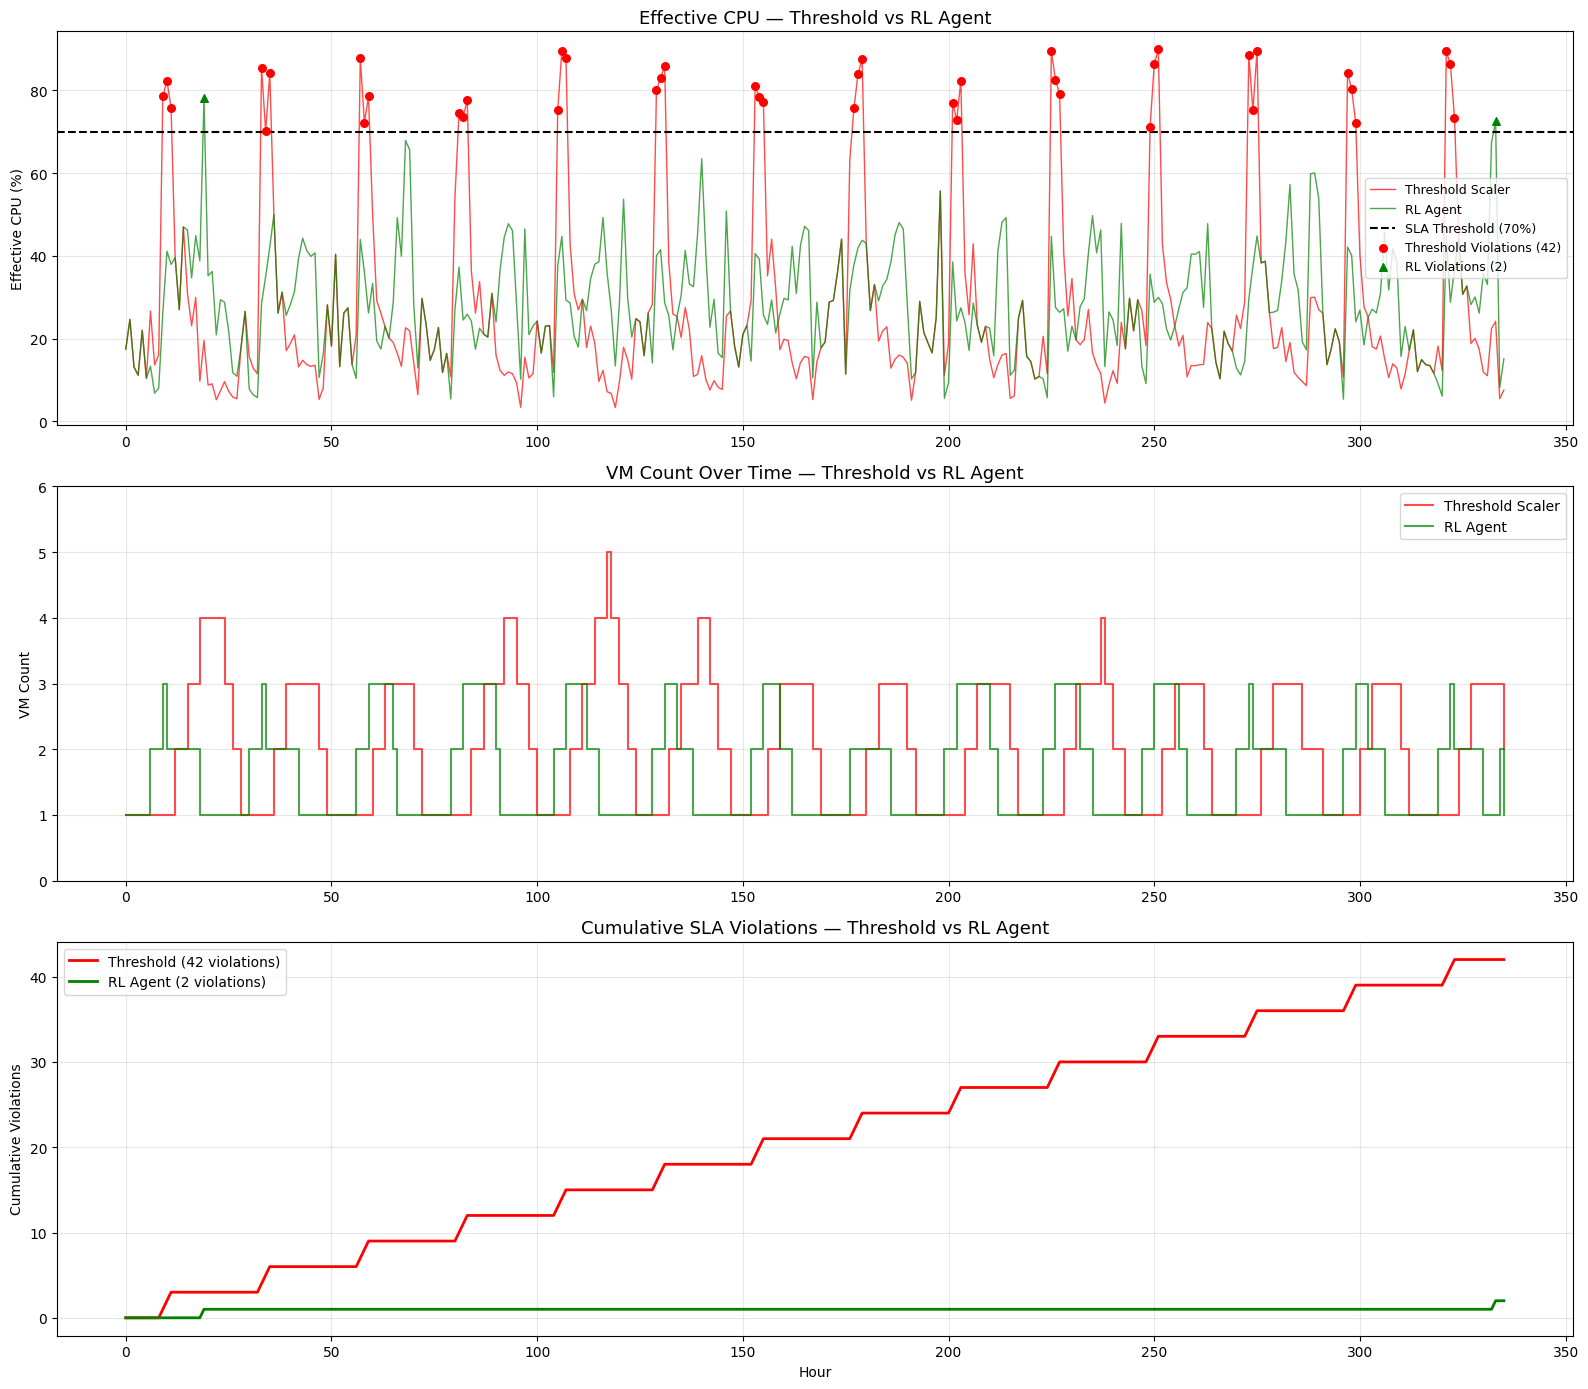

  🏆 FINAL RESULTS — RL Agent vs Threshold Baseline
  Metric              Threshold    RL Agent   Better?
  ---------------------------------------------------
  SLA Violations      42           2          ✅ YES
  Total VM Hours      666          546        ✅ YES
  Avg VMs Running     1.98         1.62       ✅ YES
  Est. Cost (14d)     $6.93        $5.68      ✅ YES
  ---------------------------------------------------
  SLA Improvement     95.2%
  Cost Improvement    18.1%


In [11]:
# ── Final Evaluation — RL Agent vs Threshold ─────────

# Run trained RL agent on full workload
eval_env  = HospitalCloudEnv(df)
obs, _    = eval_env.reset()
done      = False

while not done:
    action, _ = model.predict(obs, deterministic=True)
    obs, _, done, _, _ = eval_env.step(action)

result_rl = pd.DataFrame(eval_env.history)

# ── Cost calculation ──────────────────────────────────
cost_per_vm_hour = 0.0104
rl_cost          = eval_env.total_vm_hours * cost_per_vm_hour
threshold_cost   = 666 * cost_per_vm_hour

# ── Plot Final Comparison ─────────────────────────────
fig, axes = plt.subplots(3, 1, figsize=(16, 14))

# Graph 1 — SLA Violations comparison
axes[0].plot(result_threshold["hour"],
             result_threshold["effective_cpu"],
             color="red", linewidth=1,
             label="Threshold Scaler", alpha=0.7)
axes[0].plot(result_rl["hour"],
             result_rl["effective_cpu"],
             color="green", linewidth=1,
             label="RL Agent", alpha=0.7)
axes[0].axhline(y=70, color="black", linestyle="--",
                linewidth=1.5, label="SLA Threshold (70%)")
axes[0].scatter(
    result_threshold[result_threshold["sla_violation"]]["hour"],
    result_threshold[result_threshold["sla_violation"]]["effective_cpu"],
    color="red", s=30, zorder=5, label=f"Threshold Violations (42)")
axes[0].scatter(
    result_rl[result_rl["sla_violation"]]["hour"],
    result_rl[result_rl["sla_violation"]]["effective_cpu"],
    color="green", s=30, marker="^", zorder=5,
    label=f"RL Violations ({eval_env.sla_violations})")
axes[0].set_title("Effective CPU — Threshold vs RL Agent",
                   fontsize=13)
axes[0].set_ylabel("Effective CPU (%)")
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)

# Graph 2 — VM Count comparison
axes[1].step(result_threshold["hour"],
             result_threshold["vms"],
             color="red", linewidth=1.5,
             where="post", label="Threshold Scaler",
             alpha=0.7)
axes[1].step(result_rl["hour"],
             result_rl["vms"],
             color="green", linewidth=1.5,
             where="post", label="RL Agent", alpha=0.7)
axes[1].set_title("VM Count Over Time — Threshold vs RL Agent",
                   fontsize=13)
axes[1].set_ylabel("VM Count")
axes[1].set_ylim(0, 6)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Graph 3 — Cumulative SLA violations
axes[2].plot(result_threshold["hour"],
             result_threshold["sla_violation"].cumsum(),
             color="red", linewidth=2,
             label=f"Threshold (42 violations)")
axes[2].plot(result_rl["hour"],
             result_rl["sla_violation"].cumsum(),
             color="green", linewidth=2,
             label=f"RL Agent ({eval_env.sla_violations} violations)")
axes[2].set_title("Cumulative SLA Violations — Threshold vs RL Agent",
                   fontsize=13)
axes[2].set_xlabel("Hour")
axes[2].set_ylabel("Cumulative Violations")
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("rl_vs_threshold_comparison.png", dpi=150)
plt.show()

# ── Final Results Table ───────────────────────────────
print(f"{'='*55}")
print(f"  🏆 FINAL RESULTS — RL Agent vs Threshold Baseline")
print(f"{'='*55}")
print(f"  Metric              Threshold    RL Agent   Better?")
print(f"  {'-'*51}")
print(f"  SLA Violations      42           "
      f"{eval_env.sla_violations:<10} "
      f"{'✅ YES' if eval_env.sla_violations < 42 else '❌ NO'}")
print(f"  Total VM Hours      666          "
      f"{eval_env.total_vm_hours:<10} "
      f"{'✅ YES' if eval_env.total_vm_hours < 666 else '❌ NO'}")
print(f"  Avg VMs Running     1.98         "
      f"{result_rl['vms'].mean():<10.2f} "
      f"{'✅ YES' if result_rl['vms'].mean() < 1.98 else '❌ NO'}")
print(f"  Est. Cost (14d)     $6.93        "
      f"${rl_cost:<9.2f} "
      f"{'✅ YES' if rl_cost < 6.93 else '❌ NO'}")
sla_improvement = (42 - eval_env.sla_violations) / 42 * 100
cost_improvement = (6.93 - rl_cost) / 6.93 * 100
print(f"  {'-'*51}")
print(f"  SLA Improvement     {sla_improvement:.1f}%")
print(f"  Cost Improvement    {cost_improvement:.1f}%")
print(f"{'='*55}")

In [12]:
# Save all graphs for the report
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from google.colab import files

print("📥 Downloading all graphs for your report...")
files.download("hospital_workload.png")
files.download("threshold_scaler_results.png")
files.download("rl_training_progress.png")
files.download("rl_vs_threshold_comparison.png")
print("✅ All 4 graphs downloaded!")

📥 Downloading all graphs for your report...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ All 4 graphs downloaded!
